Workflow que:
- Define a bound box do estado do ES sem a ilha de trindade para reduzir o orthomosaico (menos oceano)
- 

In [1]:
import geopandas as gpd
from datetime import date
from cbers4asat import Cbers4aAPI
import matplotlib.pyplot as plt
import pandas as pd

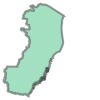

In [7]:
es = gpd.read_file("./limites/es_sem_trindade/es.shp")

es_geometry = es.union_all()
    
es_geometry

In [9]:
inicio = date(2024, 1, 1)
fim = date(2025, 11, 30)

api = Cbers4aAPI("tomir.dsj@gmail.com")

# Usar o bounding box da geometria como lista
bbox = list(es_geometry.bounds)  # [minx, miny, maxx, maxy]
print("Bounding box como lista:", bbox)

produtos = api.query(location=bbox,
                     initial_date=inicio,
                     end_date=fim,
                     cloud=40,
                     limit=2000,
                     collections=["CBERS4A_WPM_L4_DN"]
                     )

gdf = api.to_geodataframe(produtos)

gdf

Bounding box como lista: [-41.8797957, -21.301782, -39.6660146, -17.8919446]


,geometry,datetime,path,row,satellite,sensor,cloud_cover,id,bbox,collection,thumbnail
id,,,,,,,,,,,
CBERS4A_WPM19513920251011ETC2,"POLYGON ((-40.6532 -20.1182, -40.6645 -21.1647...",2025-10-11T12:44:41,195,139,CBERS4A,WPM,40.0,CBERS4A_WPM19513920251011ETC2,"[-40.6645, -21.1719, -39.5753, -20.1182]",CBERS4A_WPM_L4_DN,https://www.dgi.inpe.br/datastore/TIFF/CBERS4A...
CBERS4A_WPM19613920251006ETC2,"POLYGON ((-41.4204 -20.1178, -41.4369 -21.16, ...",2025-10-06T12:48:03,196,139,CBERS4A,WPM,20.0,CBERS4A_WPM19613920251006ETC2,"[-41.4369, -21.1721, -40.3458, -20.1178]",CBERS4A_WPM_L4_DN,https://www.dgi.inpe.br/datastore/TIFF/CBERS4A...
CBERS4A_WPM19614020251006ETC2,"POLYGON ((-41.5997 -20.9086, -41.6183 -21.9514...",2025-10-06T12:48:16,196,140,CBERS4A,WPM,0.0,CBERS4A_WPM19614020251006ETC2,"[-41.6183, -21.9651, -40.5198, -20.9086]",CBERS4A_WPM_L4_DN,https://www.dgi.inpe.br/datastore/TIFF/CBERS4A...
CBERS4A_WPM19513520250910ETC2,"POLYGON ((-39.9594 -16.9501, -39.9649 -18.0003...",2025-09-10T12:45:35,195,135,CBERS4A,WPM,10.0,CBERS4A_WPM19513520250910ETC2,"[-39.9649, -18.0027, -38.8965, -16.9501]",CBERS4A_WPM_L4_DN,https://www.dgi.inpe.br/datastore/TIFF/CBERS4A...
CBERS4A_WPM19513620250910ETC2,"POLYGON ((-40.134 -17.7417, -40.1408 -18.7922,...",2025-09-10T12:45:48,195,136,CBERS4A,WPM,10.0,CBERS4A_WPM19513620250910ETC2,"[-40.1408, -18.7957, -39.0671, -17.7417]",CBERS4A_WPM_L4_DN,https://www.dgi.inpe.br/datastore/TIFF/CBERS4A...
...,...,...,...,...,...,...,...,...,...,...,...
CBERS4A_WPM19513520240130,"POLYGON ((-39.8768 -16.9512, -39.8819 -17.9999...",2024-01-30T13:08:50,195,135,CBERS4A,WPM,20.0,CBERS4A_WPM19513520240130,"[-39.8819, -18.0018, -38.8151, -16.9512]",CBERS4A_WPM_L4_DN,https://www.dgi.inpe.br/datastore/TIFF/CBERS4A...
CBERS4A_WPM19713520240120,"POLYGON ((-41.4025 -16.9503, -41.4163 -17.992,...",2024-01-20T13:15:13,197,135,CBERS4A,WPM,40.0,CBERS4A_WPM19713520240120,"[-41.4163, -18.0023, -40.349, -16.9503]",CBERS4A_WPM_L4_DN,https://www.dgi.inpe.br/datastore/TIFF/CBERS4A...
CBERS4A_WPM19713720240120,"POLYGON ((-41.754 -18.5343, -41.7712 -19.5744,...",2024-01-20T13:15:39,197,137,CBERS4A,WPM,40.0,CBERS4A_WPM19713720240120,"[-41.7712, -19.5877, -40.692, -18.5343]",CBERS4A_WPM_L4_DN,https://www.dgi.inpe.br/datastore/TIFF/CBERS4A...


Vamos verificar se existem lacunas na cobertura das images. Traçando o mapa do ES em um polígono amarelo e as imagens recebidas em retangulos de borda vermelha.

<Axes: >

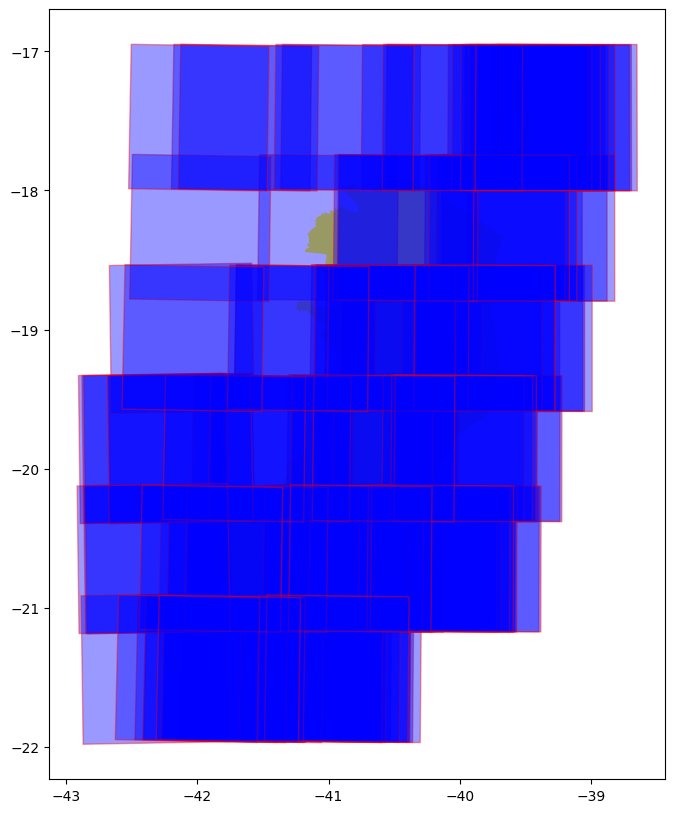

In [10]:
fig, ax = plt.subplots(figsize=(10, 10))
es.plot(ax=ax, color='yellow')
gdf.plot(ax=ax, facecolor="blue", edgecolor='red', alpha=0.4)

<Axes: >

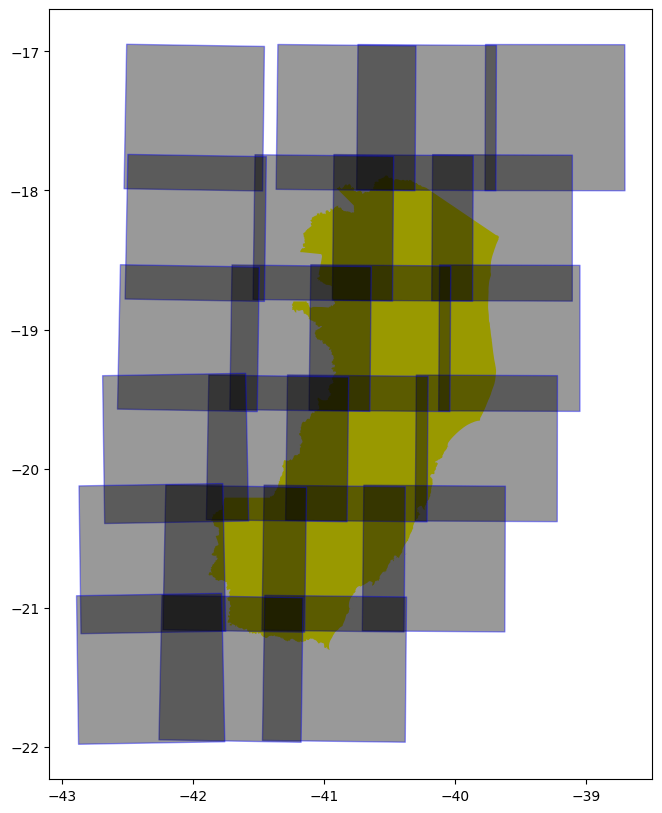

In [11]:
mosaic = gpd.GeoDataFrame()

for group_name, dframe in gdf.groupby(by=['path', 'row']):
    img = dframe.loc[(dframe.cloud_cover == dframe.cloud_cover.min())]

    img = img.loc[(img.datetime == img.datetime.min())]

    mosaic = pd.concat([mosaic, img])

fig, ax = plt.subplots(figsize=(10, 10))
es.plot(ax=ax, color="yellow")
mosaic.plot(ax=ax, facecolor="black", edgecolor='blue', alpha=0.4)

In [12]:
mosaic.to_crs(epsg=4674, inplace=True)

mosaic.crs

<Geographic 2D CRS: EPSG:4674>
Name: SIRGAS 2000
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: Latin America - Central America and South America - onshore and offshore. Brazil - onshore and offshore.
- bounds: (-122.19, -59.87, -25.28, 32.72)
Datum: Sistema de Referencia Geocentrico para las AmericaS 2000
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [13]:
mosaicos_dentro_estado = mosaic.geometry.apply(lambda g: es.intersects(g))

es_mosaic = mosaic.merge(right=mosaicos_dentro_estado, left_index=True, right_index=True) \
    .rename(columns={0: 'intersects'})

es_mosaic = es_mosaic.loc[es_mosaic['intersects'] == True]

es_mosaic.head()

,geometry,datetime,path,row,satellite,sensor,cloud_cover,id,bbox,collection,thumbnail,intersects
id,,,,,,,,,,,,
CBERS4A_WPM19513620240903,"POLYGON ((-40.1726 -17.7425, -40.1797 -18.7915...",2024-09-03T13:02:48,195,136,CBERS4A,WPM,10.0,CBERS4A_WPM19513620240903,"[-40.1797, -18.7952, -39.1075, -17.7425]",CBERS4A_WPM_L4_DN,https://www.dgi.inpe.br/datastore/TIFF/CBERS4A...,True
CBERS4A_WPM19513720250609ETC2,"POLYGON ((-40.1197 -18.5346, -40.1268 -19.5839...",2025-06-09T12:50:05,195,137,CBERS4A,WPM,0.0,CBERS4A_WPM19513720250609ETC2,"[-40.1268, -19.5874, -39.0494, -18.5346]",CBERS4A_WPM_L4_DN,https://www.dgi.inpe.br/datastore/TIFF/CBERS4A...,True
CBERS4A_WPM19513820250609ETC2,"POLYGON ((-40.2968 -19.3261, -40.3053 -20.3749...",2025-06-09T12:50:18,195,138,CBERS4A,WPM,0.0,CBERS4A_WPM19513820250609ETC2,"[-40.3053, -20.3797, -39.2213, -19.3261]",CBERS4A_WPM_L4_DN,https://www.dgi.inpe.br/datastore/TIFF/CBERS4A...,True
CBERS4A_WPM19513920240502,"POLYGON ((-40.6968 -20.1178, -40.7085 -21.1644...",2024-05-02T13:07:28,195,139,CBERS4A,WPM,10.0,CBERS4A_WPM19513920240502,"[-40.7085, -21.1719, -39.6181, -20.1178]",CBERS4A_WPM_L4_DN,https://www.dgi.inpe.br/datastore/TIFF/CBERS4A...,True
CBERS4A_WPM19613520241130ETC2,"POLYGON ((-40.7418 -16.9513, -40.7518 -17.9949...",2024-11-30T13:02:17,196,135,CBERS4A,WPM,10.0,CBERS4A_WPM19613520241130ETC2,"[-40.7518, -18.0016, -39.6861, -16.9513]",CBERS4A_WPM_L4_DN,https://www.dgi.inpe.br/datastore/TIFF/CBERS4A...,True


<Axes: >

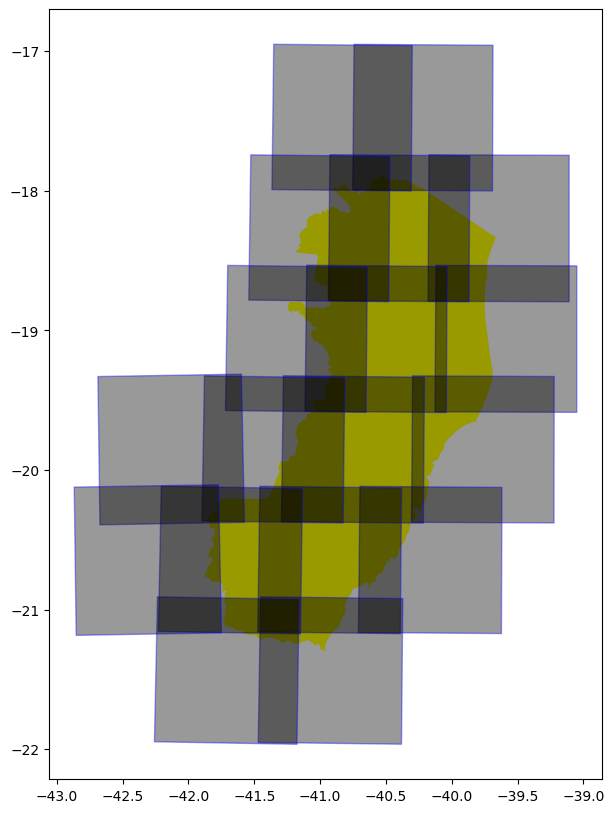

In [14]:
fig, ax = plt.subplots(figsize=(10, 10))

es.plot(ax=ax, color="yellow")

es_mosaic.plot(ax=ax, facecolor="black", edgecolor='blue', alpha=0.4)

In [15]:
import os

# Remover arquivo existente se houver
if os.path.exists("mosaico_cbers4a_es.geojson"):
    os.remove("mosaico_cbers4a_es.geojson")
    print("Arquivo existente removido")

# Salvar sem conflito de índice
es_mosaic.to_file("mosaico_cbers4a_es.geojson", driver='GeoJSON', index=False)
print("Arquivo mosaico_cbers4a_es.geojson salvo com sucesso!")

print(f"Número de imagens no mosaico: {len(es_mosaic)}")
es_mosaic.head()

Arquivo mosaico_cbers4a_es.geojson salvo com sucesso!
Número de imagens no mosaico: 18


,geometry,datetime,path,row,satellite,sensor,cloud_cover,id,bbox,collection,thumbnail,intersects
id,,,,,,,,,,,,
CBERS4A_WPM19513620240903,"POLYGON ((-40.1726 -17.7425, -40.1797 -18.7915...",2024-09-03T13:02:48,195,136,CBERS4A,WPM,10.0,CBERS4A_WPM19513620240903,"[-40.1797, -18.7952, -39.1075, -17.7425]",CBERS4A_WPM_L4_DN,https://www.dgi.inpe.br/datastore/TIFF/CBERS4A...,True
CBERS4A_WPM19513720250609ETC2,"POLYGON ((-40.1197 -18.5346, -40.1268 -19.5839...",2025-06-09T12:50:05,195,137,CBERS4A,WPM,0.0,CBERS4A_WPM19513720250609ETC2,"[-40.1268, -19.5874, -39.0494, -18.5346]",CBERS4A_WPM_L4_DN,https://www.dgi.inpe.br/datastore/TIFF/CBERS4A...,True
CBERS4A_WPM19513820250609ETC2,"POLYGON ((-40.2968 -19.3261, -40.3053 -20.3749...",2025-06-09T12:50:18,195,138,CBERS4A,WPM,0.0,CBERS4A_WPM19513820250609ETC2,"[-40.3053, -20.3797, -39.2213, -19.3261]",CBERS4A_WPM_L4_DN,https://www.dgi.inpe.br/datastore/TIFF/CBERS4A...,True
CBERS4A_WPM19513920240502,"POLYGON ((-40.6968 -20.1178, -40.7085 -21.1644...",2024-05-02T13:07:28,195,139,CBERS4A,WPM,10.0,CBERS4A_WPM19513920240502,"[-40.7085, -21.1719, -39.6181, -20.1178]",CBERS4A_WPM_L4_DN,https://www.dgi.inpe.br/datastore/TIFF/CBERS4A...,True
CBERS4A_WPM19613520241130ETC2,"POLYGON ((-40.7418 -16.9513, -40.7518 -17.9949...",2024-11-30T13:02:17,196,135,CBERS4A,WPM,10.0,CBERS4A_WPM19613520241130ETC2,"[-40.7518, -18.0016, -39.6861, -16.9513]",CBERS4A_WPM_L4_DN,https://www.dgi.inpe.br/datastore/TIFF/CBERS4A...,True


In [18]:
import os

# Criar o diretório de saída se não existir
if not os.path.exists("images_temp"):
    os.makedirs("images_temp")
    print("Diretório 'images_temp' criado")

# Iniciar o download das imagens
print("Iniciando download das imagens...")
print(f"Total de imagens para download: {len(es_mosaic)}")

api.download(es_mosaic, bands=['red', 'green', 'blue'], outdir="images_temp", with_folder=True)

Iniciando download das imagens...
Total de imagens para download: 18


In [19]:
from glob import glob
import os

# Criar diretório de saída se não existir
if not os.path.exists('images_temp/mosaico_partes'):
    os.makedirs('images_temp/mosaico_partes')
    print("Diretório 'images_temp/mosaico_partes' criado")

# Verificar se há imagens baixadas
imagens_dirs = glob("images_temp/*")
print(f"Diretórios de imagens encontrados: {len(imagens_dirs)}")

for i, dir_path in enumerate(imagens_dirs):
    files = glob(f"{dir_path}/*.tif")
    print(f"{i+1}. {dir_path}: {len(files)} arquivos .tif")

Diretório 'images_temp/mosaico_partes' criado
Diretórios de imagens encontrados: 19
1. images_temp/CBERS4A_WPM19613720240729: 3 arquivos .tif
2. images_temp/CBERS4A_WPM19613820240729: 3 arquivos .tif
3. images_temp/CBERS4A_WPM19713520250630ETC2: 3 arquivos .tif
4. images_temp/CBERS4A_WPM19713820250630ETC2: 3 arquivos .tif
5. images_temp/mosaico_partes: 0 arquivos .tif
6. images_temp/CBERS4A_WPM19714020250630ETC2: 3 arquivos .tif
7. images_temp/CBERS4A_WPM19513620240903: 3 arquivos .tif
8. images_temp/CBERS4A_WPM19713620250630ETC2: 3 arquivos .tif
9. images_temp/CBERS4A_WPM19513720250609ETC2: 3 arquivos .tif
10. images_temp/CBERS4A_WPM19613920240729: 3 arquivos .tif
11. images_temp/CBERS4A_WPM19513920240502: 3 arquivos .tif
12. images_temp/CBERS4A_WPM19614020250403ETC2: 3 arquivos .tif
13. images_temp/CBERS4A_WPM19613620240729: 3 arquivos .tif
14. images_temp/CBERS4A_WPM19813920240518: 3 arquivos .tif
15. images_temp/CBERS4A_WPM19513820250609ETC2: 3 arquivos .tif
16. images_temp/CBERS4A

In [ ]:
from os.path import basename
from cbers4asat.tools import rgbn_composite
import os
from rasterio.warp import calculate_default_transform, reproject, Resampling


processed_count = 0
error_count = 0

for dirs in glob("images_temp/*"):
    red, green, blue = '', '', ''
    img_name = ''
    
    print(f"\nProcessando: {basename(dirs)}")
    
    for file in glob(f"{dirs}/*.tif"):
        filename = basename(file)
        img_name = filename.split('_BAND')[0]  # Pegar nome antes de _BAND
        
        if 'BAND3' in filename:
            red = file
            print(f"  Red (BAND3): {filename}")
        elif 'BAND2' in filename:  # Corrigido: CBERS-4A WPM usa BAND2 para green
            green = file
            print(f"  Green (BAND2): {filename}")
        elif 'BAND1' in filename:  # Corrigido: CBERS-4A WPM usa BAND1 para blue
            blue = file
            print(f"  Blue (BAND1): {filename}")

    # Verificar se todas as bandas foram encontradas
    if red and green and blue and os.path.exists(red) and os.path.exists(green) and os.path.exists(blue):
        try:
            output_file = f'{img_name}.tif'
            print(f"  -> Criando: {output_file}")
            rgbn_composite(red=red, green=green, blue=blue, outdir='images_temp/mosaico_partes', filename=output_file)
            processed_count += 1
            print(f"  ✓ Sucesso!")
        except Exception as e:
            print(f"  ✗ Erro: {e}")
            error_count += 1
    else:
        print(f"  ✗ Bandas incompletas ou arquivos não encontrados:")
        print(f"    Red: {'✓' if red and os.path.exists(red) else '✗'}")
        print(f"    Green: {'✓' if green and os.path.exists(green) else '✗'}")
        print(f"    Blue: {'✓' if blue and os.path.exists(blue) else '✗'}")
        error_count += 1

print(f"\n" + "="*50)
print(f"Processamento concluído!")
print(f"Sucessos: {processed_count}")
print(f"Erros: {error_count}")

# Verificar arquivos criados
rgb_files = glob("images_temp/mosaico_partes/*.tif")
print(f"Arquivos RGB criados: {len(rgb_files)}")


Processando: CBERS4A_WPM19613720240729
  Red (BAND3): CBERS_4A_WPM_20240729_196_137_L4_BAND3.tif
  Blue (BAND1): CBERS_4A_WPM_20240729_196_137_L4_BAND1.tif
  Green (BAND2): CBERS_4A_WPM_20240729_196_137_L4_BAND2.tif
  -> Criando: CBERS_4A_WPM_20240729_196_137_L4.tif
  ✓ Sucesso!

Processando: CBERS4A_WPM19613820240729
  Blue (BAND1): CBERS_4A_WPM_20240729_196_138_L4_BAND1.tif
  Red (BAND3): CBERS_4A_WPM_20240729_196_138_L4_BAND3.tif
  Green (BAND2): CBERS_4A_WPM_20240729_196_138_L4_BAND2.tif
  -> Criando: CBERS_4A_WPM_20240729_196_138_L4.tif
  ✓ Sucesso!

Processando: CBERS4A_WPM19713520250630ETC2
  Red (BAND3): CBERS_4A_WPM_20250630_197_135_L4_BAND3.tif
  Blue (BAND1): CBERS_4A_WPM_20250630_197_135_L4_BAND1.tif
  Green (BAND2): CBERS_4A_WPM_20250630_197_135_L4_BAND2.tif
  -> Criando: CBERS_4A_WPM_20250630_197_135_L4.tif
  ✓ Sucesso!

Processando: CBERS4A_WPM19713820250630ETC2
  Red (BAND3): CBERS_4A_WPM_20250630_197_138_L4_BAND3.tif
  Green (BAND2): CBERS_4A_WPM_20250630_197_138_L4_B

In [23]:
from glob import glob
import rasterio
from rasterio.warp import calculate_default_transform, reproject, Resampling

# Definir a projeção de destino
dst_crs = 'EPSG:4674'

# Loop através de cada raster na pasta
for file in glob("images_temp/mosaico_partes/*.tif"):

    # Abrir o raster
    with rasterio.open(file) as src:

        # Definir as transformações de origem e destino
        transform, width, height = calculate_default_transform(
            src.crs, dst_crs, src.width, src.height, *src.bounds)
        kwargs = src.meta.copy()
        kwargs.update({
            'crs': dst_crs,
            'transform': transform,
            'width': width,
            'height': height
        })

        # Criar um arquivo de destino para o raster reprojecionado
        with rasterio.open(file, 'w', **kwargs) as dst:
            # Reprojetar o raster
            for i in range(1, src.count + 1):
                reproject(
                    source=rasterio.band(src, i),
                    destination=rasterio.band(dst, i),
                    src_transform=src.transform,
                    src_crs=src.crs,
                    dst_transform=transform,
                    dst_crs=dst_crs,
                    resampling=Resampling.cubic)

## Fusão das Imagens e Recorte Final

Agora vamos fazer a fusão (merge) de todas as imagens reprojetadas em um único mosaico e recortar pela geometria do estado do ES.

In [24]:
import rasterio
from rasterio.merge import merge
from rasterio.mask import mask
from rasterio.warp import reproject, Resampling
from glob import glob
import geopandas as gpd
import numpy as np

# Listar todas as imagens RGB processadas
rgb_files = glob("images_temp/mosaico_partes/*.tif")
print(f"Arquivos para fusão: {len(rgb_files)}")

if len(rgb_files) == 0:
    print("❌ Nenhum arquivo encontrado para fusão!")
    temp_mosaic_path = None
else:
    print(f"\nIniciando fusão de {len(rgb_files)} imagens...")
    
    # Abrir todas as imagens
    raster_list = []
    for file in rgb_files:
        try:
            src = rasterio.open(file)
            raster_list.append(src)
            print(f"✓ Carregado: {file}")
        except Exception as e:
            print(f"✗ Erro ao carregar {file}: {e}")
    
    if len(raster_list) > 0:
        # Fazer o merge das imagens
        mosaic, out_transform = merge(raster_list, method='first')
        
        # Obter metadados do primeiro raster como base
        out_meta = raster_list[0].meta.copy()
        out_meta.update({
            "driver": "GTiff",
            "height": mosaic.shape[1],
            "width": mosaic.shape[2],
            "transform": out_transform,
            "compress": "lzw",
            "BIGTIFF": "YES",  # Permitir arquivos TIFF grandes
            "tiled": True,     # Usar tiles para melhor performance
            "blockxsize": 512,
            "blockysize": 512
        })
        
        # Salvar mosaico temporário
        temp_mosaic_path = "images_temp/mosaico_temp.tif"
        with rasterio.open(temp_mosaic_path, "w", **out_meta) as dest:
            dest.write(mosaic)
        
        print("✓ Mosaico inicial criado")
        
        # Fechar arquivos abertos
        for src in raster_list:
            src.close()
    else:
        print("❌ Nenhum arquivo válido para fusão!")
        temp_mosaic_path = None

Arquivos para fusão: 18

Iniciando fusão de 18 imagens...
✓ Carregado: images_temp/mosaico_partes/CBERS_4A_WPM_20250630_197_136_L4.tif
✓ Carregado: images_temp/mosaico_partes/CBERS_4A_WPM_20240903_195_136_L4.tif
✓ Carregado: images_temp/mosaico_partes/CBERS_4A_WPM_20250403_196_140_L4.tif
✓ Carregado: images_temp/mosaico_partes/CBERS_4A_WPM_20250609_195_138_L4.tif
✓ Carregado: images_temp/mosaico_partes/CBERS_4A_WPM_20250630_197_138_L4.tif
✓ Carregado: images_temp/mosaico_partes/CBERS_4A_WPM_20240518_198_138_L4.tif
✓ Carregado: images_temp/mosaico_partes/CBERS_4A_WPM_20240729_196_137_L4.tif
✓ Carregado: images_temp/mosaico_partes/CBERS_4A_WPM_20250630_197_140_L4.tif
✓ Carregado: images_temp/mosaico_partes/CBERS_4A_WPM_20250609_195_137_L4.tif
✓ Carregado: images_temp/mosaico_partes/CBERS_4A_WPM_20240502_195_139_L4.tif
✓ Carregado: images_temp/mosaico_partes/CBERS_4A_WPM_20240924_197_139_L4.tif
✓ Carregado: images_temp/mosaico_partes/CBERS_4A_WPM_20250630_197_135_L4.tif
✓ Carregado: image

In [ ]:
if temp_mosaic_path and len(rgb_files) > 0:
    print("Iniciando recorte pela geometria do Estado do ES...")
    
    # Garantir que es_geometry esteja no mesmo CRS do mosaico
    es_gdf = gpd.GeoDataFrame([1], geometry=[es_geometry], crs='EPSG:4674')
    
    # Abrir o mosaico temporário
    with rasterio.open(temp_mosaic_path) as src:
        print(f"CRS do mosaico: {src.crs}")
        print(f"Dimensões do mosaico: {src.width} x {src.height}")
        print(f"Bounds do mosaico: {src.bounds}")
        
        # Calcular tamanho em GB aproximado
        size_gb = (src.width * src.height * src.count * 2) / (1024**3)  # assumindo uint16
        print(f"Tamanho aproximado: {size_gb:.1f} GB")
        
        # Reprojetar a geometria se necessário
        if str(src.crs) != 'EPSG:4674':
            es_gdf = es_gdf.to_crs(src.crs)
            print(f"Geometria reprojetada para: {src.crs}")
        
        # Fazer o recorte usando a geometria do ES
        try:
            print("⚠️ Processando recorte (pode demorar devido ao tamanho)...")
            
            # Usar windowed reading para economizar memória
            from rasterio.windows import from_bounds
            
            # Calcular window baseado na geometria
            geom_bounds = es_gdf.total_bounds
            window = from_bounds(*geom_bounds, src.transform)
            
            print(f"Window calculada: {window}")
            
            # Fazer recorte com mask - mais eficiente para geometrias
            out_image, out_transform = mask(src, es_gdf.geometry, crop=True, nodata=0, filled=True)
            
            print(f"Recorte concluído. Nova dimensão: {out_image.shape}")
            
            out_meta = src.meta.copy()
            out_meta.update({
                "driver": "GTiff",
                "height": out_image.shape[1],
                "width": out_image.shape[2],
                "transform": out_transform,
                "nodata": 0,
                "compress": "lzw",
                "BIGTIFF": "YES",  # Permitir arquivos TIFF grandes
                "tiled": True,     # Usar tiles para melhor performance
                "blockxsize": 512,
                "blockysize": 512
            })
            
            # Salvar o mosaico final recortado
            final_mosaic_path = "images_temp/mosaico_final_es.tif"
            print("💾 Salvando arquivo final...")
            
            with rasterio.open(final_mosaic_path, "w", **out_meta) as dest:
                dest.write(out_image)
            
            print(f"✅ Mosaico final salvo em: {final_mosaic_path}")
            print(f"Dimensões finais: {out_image.shape[2]} x {out_image.shape[1]}")
            
            # Limpar variável da memória
            del out_image
            
            # Remover arquivo temporário
            import os
            if os.path.exists(temp_mosaic_path):
                os.remove(temp_mosaic_path)
                print("🗑️ Arquivo temporário removido")
                
        except MemoryError:
            print("❌ Erro de memória. O mosaico é muito grande para processar.")
            print("💡 Sugestão: Execute em um ambiente com mais RAM ou processe em partes.")
        except Exception as e:
            print(f"❌ Erro durante o recorte: {e}")
            import traceback
            traceback.print_exc()
            
else:
    print("❌ Não foi possível criar o mosaico inicial")

Iniciando recorte pela geometria do Estado do ES...
CRS do mosaico: EPSG:4674
Dimensões do mosaico: 53951 x 67994
Bounds do mosaico: BoundingBox(left=-42.85598621652549, bottom=-21.964892903159658, right=-38.87754182004282, top=-16.95089226750058)
Tamanho aproximado: 20.5 GB
⚠️ Processando recorte (pode demorar devido ao tamanho)...
Window calculada: Window(col_off=np.float64(13237.951648546034), row_off=np.float64(12761.448780222301), width=np.float64(30020.70463312068), height=np.float64(46240.2183451507))
CRS do mosaico: EPSG:4674
Dimensões do mosaico: 53951 x 67994
Bounds do mosaico: BoundingBox(left=-42.85598621652549, bottom=-21.964892903159658, right=-38.87754182004282, top=-16.95089226750058)
Tamanho aproximado: 20.5 GB
⚠️ Processando recorte (pode demorar devido ao tamanho)...
Window calculada: Window(col_off=np.float64(13237.951648546034), row_off=np.float64(12761.448780222301), width=np.float64(30020.70463312068), height=np.float64(46240.2183451507))


: 

### ⚠️ Importante - Gestão de Memória

O mosaico gerado é muito grande (~3.6 bilhões de pixels). Se houver problemas de memória:

1. **Reinicie o kernel** antes de executar a célula de recorte
2. **Execute apenas as células essenciais**: células 1, 3, e a de recorte
3. **Considere processar em um ambiente com mais RAM** (16GB+ recomendado)

---

## Visualização do Resultado Final

Vamos visualizar o mosaico final para verificar o resultado.

In [ ]:
import matplotlib.pyplot as plt
import rasterio
from rasterio.plot import show
import numpy as np
import os

# Verificar se o arquivo final foi criado
final_mosaic_path = "images_temp/mosaico_final_es.tif"

if os.path.exists(final_mosaic_path):
    print("📊 Carregando mosaico final para visualização...")
    
    # Abrir e visualizar o mosaico final
    with rasterio.open(final_mosaic_path) as src:
        # Ler os dados
        data = src.read()
        
        print(f"✅ Mosaico carregado com sucesso!")
        print(f"📏 Dimensões: {src.width} x {src.height} pixels")
        print(f"📦 Bandas: {src.count}")
        print(f"🌍 CRS: {src.crs}")
        print(f"📍 Bounds: {src.bounds}")
        
        # Criar visualização
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))
        
        # Mostrar o mosaico RGB
        if src.count >= 3:
            # Normalizar os valores para visualização
            rgb = data[:3].transpose(1, 2, 0)
            
            # Remover pixels com valor 0 (nodata) para melhor visualização
            rgb_vis = rgb.copy()
            rgb_vis[rgb_vis == 0] = np.nan
            
            # Normalizar para 0-1 se necessário
            if rgb_vis.max() > 1:
                rgb_vis = rgb_vis / rgb_vis.max()
            
            ax1.imshow(rgb_vis, extent=[src.bounds.left, src.bounds.right, 
                                       src.bounds.bottom, src.bounds.top])
            ax1.set_title('Mosaico Final - Estado do ES', fontsize=14, fontweight='bold')
            ax1.set_xlabel('Longitude')
            ax1.set_ylabel('Latitude')
            
            # Sobrepor o limite do estado
            es_gdf = gpd.GeoDataFrame([1], geometry=[es_geometry], crs='EPSG:4674')
            es_gdf.boundary.plot(ax=ax1, color='red', linewidth=2, alpha=0.8)
            
        else:
            show(src, ax=ax1, title='Mosaico Final - Estado do ES')
        
        # Mostrar histograma das bandas
        for i in range(min(3, src.count)):
            band_data = data[i][data[i] > 0]  # Excluir nodata
            if len(band_data) > 0:
                ax2.hist(band_data.flatten(), bins=100, alpha=0.7, 
                        label=f'Banda {i+1}', density=True)
        
        ax2.set_title('Histograma das Bandas RGB')
        ax2.set_xlabel('Valor do Pixel')
        ax2.set_ylabel('Densidade')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # Estatísticas finais
        print(f"\n📊 Estatísticas do Mosaico Final:")
        for i in range(src.count):
            band_data = data[i][data[i] > 0]
            if len(band_data) > 0:
                print(f"   Banda {i+1}: Min={band_data.min():.2f}, Max={band_data.max():.2f}, Média={band_data.mean():.2f}")
        
        print(f"\n🎉 PROCESSO CONCLUÍDO COM SUCESSO!")
        print(f"📁 Arquivo final: {final_mosaic_path}")
        print(f"💾 Tamanho do arquivo: {os.path.getsize(final_mosaic_path) / (1024*1024):.1f} MB")
        
else:
    print("❌ Arquivo mosaico_final_es.tif não encontrado!")
    print("   Verifique se as etapas anteriores foram executadas com sucesso.")

## Resumo do Workflow Completo

Este notebook implementou um workflow completo para gerar um ortomosaico do estado do Espírito Santo usando imagens CBERS-4A:

### 📋 Etapas Realizadas:

1. **📍 Definição da Área de Interesse**: Carregamento do shapefile do ES sem a ilha de Trindade
2. **🔍 Consulta de Imagens**: Busca por imagens CBERS-4A de janeiro a novembro de 2025
3. **📊 Análise de Cobertura**: Visualização da cobertura espacial das imagens encontradas
4. **🎯 Seleção Otimizada**: Escolha da melhor imagem por path/row (menor cobertura de nuvens)
5. **💾 Download**: Download das bandas RGB (BAND1, BAND2, BAND3) para `/Volumes/Mestrado/imagens`
6. **🌈 Composição RGB**: Criação de compostos RGB usando a combinação correta para CBERS-4A WPM
7. **🗺️ Reprojeção**: Padronização para EPSG:4674 (SIRGAS 2000)
8. **🔀 Fusão**: Merge de todas as imagens em um único mosaico
9. **✂️ Recorte Final**: Clipping pela geometria do estado do ES
10. **📊 Visualização**: Apresentação do resultado final

### 📁 Arquivos Gerados:
- `mosaico_cbers4a_es.geojson`: Metadados das imagens selecionadas
- `/Volumes/Mestrado/imagens/*`: Imagens CBERS-4A originais por pasta
- `/Volumes/Mestrado/mosaico_partes/*`: Compostos RGB individuais
- `/Volumes/Mestrado/mosaico_final_es.tif`: **RESULTADO FINAL** 

### 🎯 Resultado:
Um ortomosaico RGB de alta qualidade do estado do Espírito Santo, reprojetado em SIRGAS 2000, pronto para análises geoespaciais e visualizações.